In [150]:
import pandas as pd

In [151]:
medical_df=pd.read_csv("medical-charges.csv")

In [152]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [153]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [154]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [155]:
import matplotlib
import matplotlib.pyplot as plt

In [156]:
%matplotlib inline

In [157]:
medical_df.age.corr(medical_df["charges"])

np.float64(0.29900819333064776)

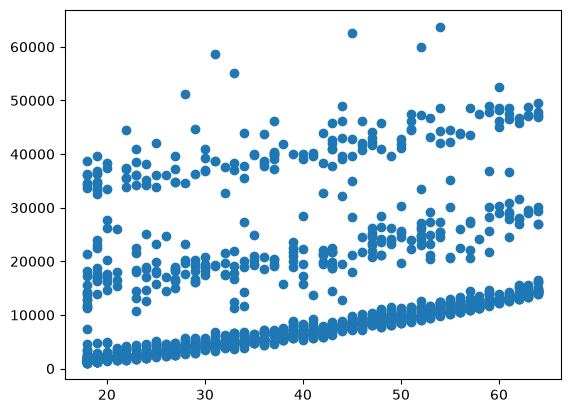

In [158]:
plt.scatter(medical_df["age"],medical_df["charges"])
plt.show()

In [159]:
mapping={"yes":1,"no":0}
medical_df["smoker_code"]=medical_df["smoker"].map(mapping)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [160]:
non_smoker=medical_df[medical_df["smoker_code"]==1]
non_smoker

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
11,62,female,26.290,0,yes,southeast,27808.72510,1
14,27,male,42.130,0,yes,southeast,39611.75770,1
19,30,male,35.300,0,yes,southwest,36837.46700,1
23,34,female,31.920,1,yes,northeast,37701.87680,1
...,...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600,1
1314,30,female,23.655,3,yes,northwest,18765.87545,1
1321,62,male,26.695,0,yes,northeast,28101.33305,1
1323,42,female,40.370,2,yes,southeast,43896.37630,1


In [161]:
smoker=medical_df[medical_df["smoker_code"]==0]
smoker

,age,sex,bmi,children,smoker,region,charges,smoker_code
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
5,31,female,25.740,0,no,southeast,3756.62160,0
...,...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500,0
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0


In [162]:
medical_df.smoker_code.corr(medical_df["charges"])

np.float64(0.7872514304984778)

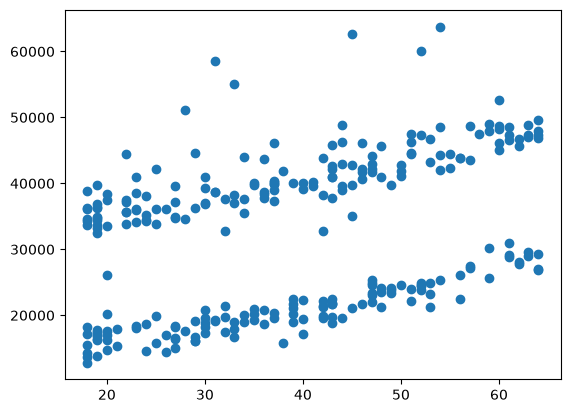

In [163]:
plt.scatter(non_smoker["age"],non_smoker["charges"])
plt.show()


In [164]:
def estimate_charge(age,w,b):
    return age*w+b
w=300
b=15000


In [165]:
ages=non_smoker.age
estimate_cost=estimate_charge(ages,w,b)
estimate_cost

0       20700
11      33600
14      23100
19      24000
23      25200
        ...  
1313    20700
1314    24000
1321    33600
1323    27600
1337    33300
Name: age, Length: 274, dtype: int64

In [166]:
non_smoker.age

0       19
11      62
14      27
19      30
23      34
        ..
1313    19
1314    30
1321    62
1323    42
1337    61
Name: age, Length: 274, dtype: int64

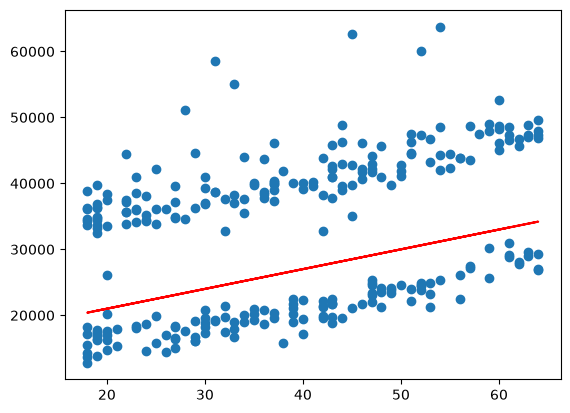

In [167]:
plt.scatter(non_smoker["age"],non_smoker["charges"])
plt.plot(non_smoker["age"],estimate_cost,"r-")
plt.show()


In [168]:
import numpy as np


In [169]:
rmse(non_smoker.charges,estimate_cost)

np.float64(12038.907068663006)

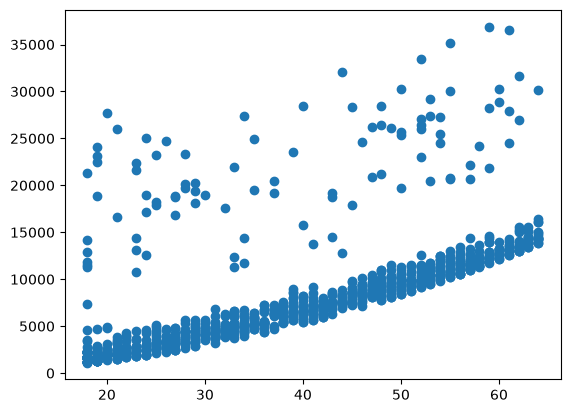

In [170]:
plt.scatter(smoker["age"],smoker["charges"])
plt.show()

In [171]:
def smoker_estimated_cost(smoker_age,w,b):
    return smoker_age*w+b

In [172]:
smoker_age=smoker.age
w=190
b=1700
smoker_cost=smoker_estimated_cost(smoker_age,w,b)

In [173]:
rmse(smoker.charges,smoker_cost)

np.float64(4845.859603912946)

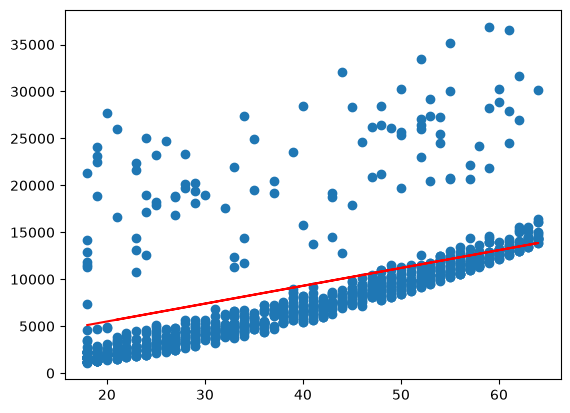

In [174]:
plt.scatter(smoker["age"],smoker["charges"])
plt.plot(smoker["age"],smoker_cost,"r-")
plt.show()


In [175]:
from sklearn.linear_model import LinearRegression

In [176]:
model=LinearRegression()

In [177]:
inputs=smoker[["age"]]
target=smoker.charges

In [179]:
model.fit(inputs,target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [180]:
result=model.predict(inputs)

In [181]:
result

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [182]:
rmse(result,smoker.charges)

np.float64(4662.505766636395)

In [184]:
model.coef_

array([267.24891283])

In [188]:
model.intercept_

np.float64(-2091.4205565650864)